# NB02 — Feature Engineering & Target Construction
## YouTube Trending: ¿Qué señales predicen cuánto dura un video en trending?

---

**Objetivo de este notebook:**  
Limpiar los datos, construir el target `days_in_trending` de forma correcta (respetando gaps de captura), y generar todas las features necesarias para el modelo.

**Issues a resolver (de NB01):**
- Eliminar duplicados
- Detectar gaps en el calendario de trending (días sin captura)
- Construir `days_in_trending` sin inflar por gaps
- Decodificar categorías (incluido MX id=29)
- Feature engineering completo
- Guardar datasets procesados como Parquet

## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11
})
PALETTE = {'MX': '#E53935', 'US': '#1E88E5'}
DATA_PATH = '../data/raw/'

mx = pd.read_csv(f'{DATA_PATH}MX_youtube_trending_data.csv', parse_dates=['publishedAt', 'trending_date'])
us = pd.read_csv(f'{DATA_PATH}US_youtube_trending_data.csv', parse_dates=['publishedAt', 'trending_date'])
mx['region'] = 'MX'
us['region'] = 'US'

print(f'Loaded MX: {mx.shape} | US: {us.shape}')

Loaded MX: (268598, 17) | US: (268787, 17)


## 2. Deduplication

In [2]:
def deduplicate(df, name):
    n0 = len(df)
    # 1. Remove exact duplicates
    df = df.drop_duplicates()
    n1 = len(df)
    # 2. For same video on same day, keep the row with highest view_count
    df = df.sort_values('view_count', ascending=False)
    df = df.drop_duplicates(subset=['video_id', 'trending_date'], keep='first')
    n2 = len(df)
    print(f'{name}: {n0:,} → after exact dedup: {n1:,} → after video+date dedup: {n2:,}  (removed {n0-n2:,} rows)')
    return df.reset_index(drop=True)

mx = deduplicate(mx, 'MX')
us = deduplicate(us, 'US')

MX: 268,598 → after exact dedup: 268,528 → after video+date dedup: 264,472  (removed 4,126 rows)


US: 268,787 → after exact dedup: 268,704 → after video+date dedup: 264,717  (removed 4,070 rows)


## 3. Gap Detection in Trending Calendar

Un gap es un día en que no hubo captura de datos. Si un video estuvo en trending el día 1 y reaparece el día 4 habiendo un gap en los días 2 y 3, no podemos asumir que estuvo trending esos días — podría haber salido y vuelto a entrar, o simplemente no se capturó. **La estrategia conservadora: un video solo acumula días consecutivos sin gaps.**

In [3]:
def find_gaps(df, name):
    """Returns set of dates where no trending capture happened."""
    all_dates = pd.date_range(
        df['trending_date'].min(),
        df['trending_date'].max(),
        freq='D', tz='UTC'
    )
    captured = set(df['trending_date'].dt.normalize().unique())
    gaps = set(all_dates) - captured
    print(f'{name}: {len(all_dates)} calendar days | {len(captured)} captured | {len(gaps)} gaps ({len(gaps)/len(all_dates)*100:.1f}%)')
    return gaps

gaps_mx = find_gaps(mx, 'MX')
gaps_us = find_gaps(us, 'US')

MX: 1343 calendar days | 1322 captured | 21 gaps (1.6%)
US: 1343 calendar days | 1323 captured | 20 gaps (1.5%)


## 4. Target Construction: `days_in_trending`

**Lógica:**  
Para cada `video_id` en una región, contamos cuántos días consecutivos aparece en trending, **romping la secuencia si hay un gap de captura entre apariciones**. El target es el **número total de días** en el primer streak continuo (o el máximo streak, que es equivalente para efectos del modelo).

Estrategia: para cada video, ordenamos sus apariciones por fecha y contamos rachas continuas usando diferencias de 1 día.

In [4]:
def compute_days_in_trending(df, gap_dates):
    """
    For each video, compute the maximum consecutive-day streak in trending,
    excluding days that fall in gap_dates.
    Returns a Series indexed by video_id with days_in_trending values.
    """
    records = []
    gap_set = {pd.Timestamp(d).normalize() for d in gap_dates}

    for vid, grp in df.groupby('video_id'):
        dates = sorted(grp['trending_date'].dt.normalize().unique())
        if len(dates) == 1:
            records.append({'video_id': vid, 'days_in_trending': 1})
            continue

        max_streak = 1
        current_streak = 1
        for i in range(1, len(dates)):
            diff = (dates[i] - dates[i-1]).days
            # Check if the gap between dates[i-1] and dates[i] contains only gap days
            days_between = [(dates[i-1] + pd.Timedelta(days=d)) for d in range(1, diff)]
            all_gaps = all(d in gap_set for d in days_between)

            if diff == 1 or (diff > 1 and all_gaps):
                current_streak += 1
            else:
                max_streak = max(max_streak, current_streak)
                current_streak = 1
        max_streak = max(max_streak, current_streak)
        records.append({'video_id': vid, 'days_in_trending': max_streak})

    return pd.DataFrame(records).set_index('video_id')['days_in_trending']

print('Computing days_in_trending for MX...')
dit_mx = compute_days_in_trending(mx, gaps_mx)
print(f'MX done: {len(dit_mx):,} unique videos')

print('Computing days_in_trending for US...')
dit_us = compute_days_in_trending(us, gaps_us)
print(f'US done: {len(dit_us):,} unique videos')

Computing days_in_trending for MX...


MX done: 32,442 unique videos
Computing days_in_trending for US...


US done: 47,142 unique videos


## 5. Target Distribution

MX — percentiles: P25=6d | P50=8d | P75=9d | P90=11d | P95=13d | Max=26d
US — percentiles: P25=4d | P50=5d | P75=6d | P90=7d | P95=8d | Max=37d


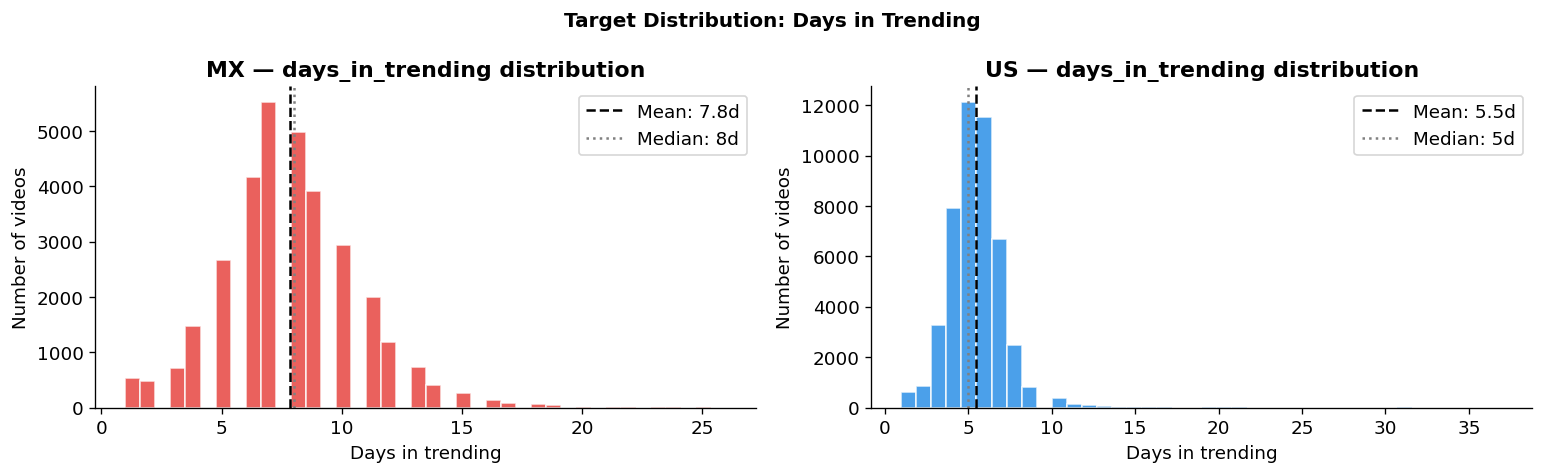

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (name, dit) in zip(axes, [('MX', dit_mx), ('US', dit_us)]):
    ax.hist(dit.values, bins=40, color=PALETTE[name], alpha=0.8, edgecolor='white')
    ax.axvline(dit.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {dit.mean():.1f}d')
    ax.axvline(dit.median(), color='gray', linestyle=':', linewidth=1.5,
               label=f'Median: {dit.median():.0f}d')
    ax.set_xlabel('Days in trending')
    ax.set_ylabel('Number of videos')
    ax.set_title(f'{name} — days_in_trending distribution', fontweight='bold')
    ax.legend()

    p = np.percentile(dit.values, [25, 50, 75, 90, 95])
    print(f'{name} — percentiles: P25={p[0]:.0f}d | P50={p[1]:.0f}d | P75={p[2]:.0f}d | P90={p[3]:.0f}d | P95={p[4]:.0f}d | Max={dit.max():.0f}d')

plt.suptitle('Target Distribution: Days in Trending', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_05_target_distribution.png', bbox_inches='tight')
plt.show()

**Interpretación:**  
La distribución del target es fuertemente sesgada a la derecha: la mayoría de los videos aparece en trending solo 1–3 días, pero existe una cola de videos que permanecen semanas. Esto es esperado — el trending de YouTube es un sistema competitivo donde pocos videos dominan por largos períodos. Esta distribución guía dos decisiones:
1. Aplicar **log-transformación** al target para el modelo de regresión
2. Considerar también una **clasificación binaria** (alta durabilidad vs baja) si el R² del modelo de regresión resulta bajo

## 6. Build Modeling Dataset

Para el modelo, necesitamos **una fila por video** (no por video-día). Tomamos el **primer día en trending** de cada video, porque ese es el momento en que un creador podría predecir la durabilidad — usando solo las señales del día 1.

In [6]:
def build_first_day(df, dit):
    """Take the first trending appearance of each video."""
    first = (df.sort_values('trending_date')
               .drop_duplicates(subset='video_id', keep='first')
               .copy())
    first = first.join(dit.rename('days_in_trending'), on='video_id')
    return first

mx_model = build_first_day(mx, dit_mx)
us_model = build_first_day(us, dit_us)

print(f'MX modeling rows: {len(mx_model):,}')
print(f'US modeling rows: {len(us_model):,}')
print(f'Target nulls — MX: {mx_model["days_in_trending"].isna().sum()} | US: {us_model["days_in_trending"].isna().sum()}')

MX modeling rows: 32,442
US modeling rows: 47,142
Target nulls — MX: 0 | US: 0


## 7. Category Mapping

In [7]:
def load_category_map(json_path):
    with open(json_path) as f:
        data = json.load(f)
    return {int(item['id']): item['snippet']['title'] for item in data['items']}

cat_mx = load_category_map(f'{DATA_PATH}MX_category_id.json')
cat_us = load_category_map(f'{DATA_PATH}US_category_id.json')

# MX category 29 is missing from MX JSON but exists in US JSON
cat_mx[29] = cat_us.get(29, 'Nonprofits & Activism')

mx_model['category_name'] = mx_model['categoryId'].map(lambda x: cat_mx.get(int(x), 'Unknown') if pd.notna(x) else 'Unknown')
us_model['category_name'] = us_model['categoryId'].map(lambda x: cat_us.get(int(x), 'Unknown') if pd.notna(x) else 'Unknown')

print('MX category distribution (top 10):')
print(mx_model['category_name'].value_counts().head(10).to_string())
print('\nUS category distribution (top 10):')
print(us_model['category_name'].value_counts().head(10).to_string())

MX category distribution (top 10):
category_name
Entertainment       7676
Music               7173
Gaming              4807
People & Blogs      3972
Sports              3596
News & Politics     1412
Comedy              1170
Film & Animation     812
Howto & Style        795
Autos & Vehicles     294

US category distribution (top 10):
category_name
Gaming                  9436
Entertainment           9192
Music                   7340
Sports                  6070
People & Blogs          4041
Comedy                  2251
Film & Animation        1838
News & Politics         1731
Science & Technology    1424
Howto & Style           1219


## 8. Feature Engineering

In [8]:
def engineer_features(df):
    df = df.copy()

    # ── Temporal features ──────────────────────────────────────────────────
    df['days_to_trending'] = (
        (df['trending_date'] - df['publishedAt'])
        .dt.total_seconds() / 86400
    ).clip(lower=0).round(1)

    df['publish_hour']      = df['publishedAt'].dt.hour
    df['publish_dayofweek'] = df['publishedAt'].dt.dayofweek  # 0=Mon
    df['publish_month']     = df['publishedAt'].dt.month
    df['publish_year']      = df['publishedAt'].dt.year

    # ── Engagement ratios ──────────────────────────────────────────────────
    eps = 1  # avoid division by zero
    df['like_rate']    = df['likes']         / (df['view_count'] + eps)
    df['comment_rate'] = df['comment_count'] / (df['view_count'] + eps)

    # ── Log-transformed engagement ─────────────────────────────────────────
    df['log_views']   = np.log1p(df['view_count'])
    df['log_likes']   = np.log1p(df['likes'])
    df['log_comments']= np.log1p(df['comment_count'])

    # ── Title features ─────────────────────────────────────────────────────
    df['title_length']    = df['title'].fillna('').str.len()
    df['title_word_count']= df['title'].fillna('').str.split().str.len()
    df['title_has_caps']  = df['title'].fillna('').str.contains(r'[A-Z]{3,}').astype(int)
    df['title_has_excl']  = df['title'].fillna('').str.contains(r'!').astype(int)
    df['title_has_question'] = df['title'].fillna('').str.contains(r'\?').astype(int)
    df['title_has_number']   = df['title'].fillna('').str.contains(r'\d').astype(int)

    # ── Tags features ──────────────────────────────────────────────────────
    df['tag_count'] = df['tags'].apply(
        lambda x: len(str(x).split('|')) if pd.notna(x) and str(x) != '[none]' else 0
    )
    df['has_tags'] = (df['tag_count'] > 0).astype(int)

    # ── Description features ───────────────────────────────────────────────
    df['has_description']  = df['description'].notna().astype(int)
    df['desc_length']      = df['description'].fillna('').str.len()
    df['desc_has_url']     = df['description'].fillna('').str.contains(r'http').astype(int)
    df['desc_has_hashtag'] = df['description'].fillna('').str.contains(r'#').astype(int)

    # ── Boolean flags → int ────────────────────────────────────────────────
    df['comments_disabled'] = df['comments_disabled'].astype(int)
    df['ratings_disabled']  = df['ratings_disabled'].astype(int)

    # ── Log target ─────────────────────────────────────────────────────────
    df['log_days_in_trending'] = np.log1p(df['days_in_trending'])

    return df

mx_model = engineer_features(mx_model)
us_model = engineer_features(us_model)

new_features = ['days_to_trending', 'publish_hour', 'publish_dayofweek', 'publish_month',
                'like_rate', 'comment_rate', 'log_views', 'log_likes', 'log_comments',
                'title_length', 'title_word_count', 'title_has_caps', 'title_has_excl',
                'title_has_question', 'title_has_number', 'tag_count', 'has_tags',
                'has_description', 'desc_length', 'desc_has_url', 'desc_has_hashtag',
                'comments_disabled', 'ratings_disabled']

print(f'Features engineered: {len(new_features)}')
print(f'MX model shape: {mx_model.shape}')
print(f'US model shape: {us_model.shape}')

Features engineered: 23
MX model shape: (32442, 42)
US model shape: (47142, 42)


## 9. Feature Summary Table

In [9]:
feat_summary = pd.DataFrame([
    {'Feature': 'days_to_trending',    'Type': 'Temporal',    'Description': 'Days between publish and first trending appearance'},
    {'Feature': 'publish_hour',        'Type': 'Temporal',    'Description': 'Hour of day when video was published (0–23)'},
    {'Feature': 'publish_dayofweek',   'Type': 'Temporal',    'Description': 'Day of week (0=Mon, 6=Sun)'},
    {'Feature': 'publish_month',       'Type': 'Temporal',    'Description': 'Month of publication (1–12)'},
    {'Feature': 'log_views',           'Type': 'Engagement',  'Description': 'Log(1 + view_count) on day 1 of trending'},
    {'Feature': 'log_likes',           'Type': 'Engagement',  'Description': 'Log(1 + likes) on day 1'},
    {'Feature': 'log_comments',        'Type': 'Engagement',  'Description': 'Log(1 + comment_count) on day 1'},
    {'Feature': 'like_rate',           'Type': 'Engagement',  'Description': 'likes / view_count — quality engagement ratio'},
    {'Feature': 'comment_rate',        'Type': 'Engagement',  'Description': 'comments / view_count — conversation ratio'},
    {'Feature': 'title_length',        'Type': 'Title NLP',   'Description': 'Number of characters in title'},
    {'Feature': 'title_word_count',    'Type': 'Title NLP',   'Description': 'Number of words in title'},
    {'Feature': 'title_has_caps',      'Type': 'Title NLP',   'Description': 'Title contains 3+ consecutive uppercase letters'},
    {'Feature': 'title_has_excl',      'Type': 'Title NLP',   'Description': 'Title contains exclamation mark'},
    {'Feature': 'title_has_question',  'Type': 'Title NLP',   'Description': 'Title contains question mark'},
    {'Feature': 'title_has_number',    'Type': 'Title NLP',   'Description': 'Title contains a digit'},
    {'Feature': 'tag_count',           'Type': 'SEO',         'Description': 'Number of tags assigned to the video'},
    {'Feature': 'has_tags',            'Type': 'SEO',         'Description': 'Binary: video has at least 1 tag'},
    {'Feature': 'has_description',     'Type': 'Content',     'Description': 'Binary: video has a description'},
    {'Feature': 'desc_length',         'Type': 'Content',     'Description': 'Number of characters in description'},
    {'Feature': 'desc_has_url',        'Type': 'Content',     'Description': 'Description contains a URL'},
    {'Feature': 'desc_has_hashtag',    'Type': 'Content',     'Description': 'Description contains a hashtag'},
    {'Feature': 'category_name',       'Type': 'Categorical', 'Description': 'Video category (decoded from categoryId JSON)'},
    {'Feature': 'comments_disabled',   'Type': 'Flags',       'Description': 'Comments are disabled (1=yes)'},
    {'Feature': 'ratings_disabled',    'Type': 'Flags',       'Description': 'Ratings are disabled (1=yes)'},
])

display(feat_summary.style.set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

,Feature,Type,Description
0,days_to_trending,Temporal,Days between publish and first trending appearance
1,publish_hour,Temporal,Hour of day when video was published (0–23)
2,publish_dayofweek,Temporal,"Day of week (0=Mon, 6=Sun)"
3,publish_month,Temporal,Month of publication (1–12)
4,log_views,Engagement,Log(1 + view_count) on day 1 of trending
5,log_likes,Engagement,Log(1 + likes) on day 1
6,log_comments,Engagement,Log(1 + comment_count) on day 1
7,like_rate,Engagement,likes / view_count — quality engagement ratio
8,comment_rate,Engagement,comments / view_count — conversation ratio
9,title_length,Title NLP,Number of characters in title


## 10. Null Check After Engineering

In [10]:
model_features = new_features + ['category_name', 'days_in_trending', 'log_days_in_trending', 'region']

for name, df in [('MX', mx_model), ('US', us_model)]:
    nulls = df[model_features].isna().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) == 0:
        print(f'{name}: No nulls in model features ✓')
    else:
        print(f'{name}: Nulls found:')
        print(nulls)

MX: No nulls in model features ✓
US: No nulls in model features ✓


## 11. days_to_trending — Anomaly Check

MX: 64.2% of videos reached trending within 1 day of publishing
       Median: 1d | P95: 2d | Max: 30d
US: 61.3% of videos reached trending within 1 day of publishing
       Median: 1d | P95: 2d | Max: 29d


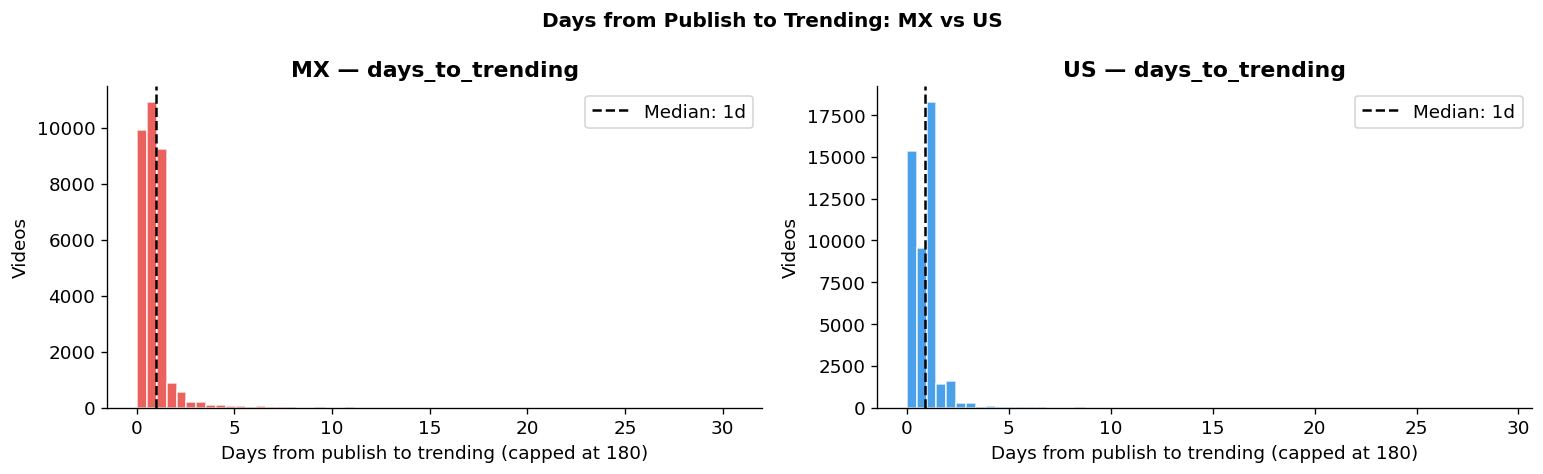

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (name, df) in zip(axes, [('MX', mx_model), ('US', us_model)]):
    # Cap at 365 days for readability
    d2t = df['days_to_trending'].clip(upper=180)
    ax.hist(d2t, bins=60, color=PALETTE[name], alpha=0.8, edgecolor='white')
    ax.axvline(df['days_to_trending'].median(), color='black', linestyle='--',
               label=f'Median: {df["days_to_trending"].median():.0f}d')
    ax.set_xlabel('Days from publish to trending (capped at 180)')
    ax.set_ylabel('Videos')
    ax.set_title(f'{name} — days_to_trending', fontweight='bold')
    ax.legend()
    pct_fast = (df['days_to_trending'] <= 1).mean() * 100
    print(f'{name}: {pct_fast:.1f}% of videos reached trending within 1 day of publishing')
    print(f'       Median: {df["days_to_trending"].median():.0f}d | P95: {df["days_to_trending"].quantile(.95):.0f}d | Max: {df["days_to_trending"].max():.0f}d')

plt.suptitle('Days from Publish to Trending: MX vs US', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_06_days_to_trending.png', bbox_inches='tight')
plt.show()

**Interpretación:**  
Una parte significativa de los videos llega a trending en el mismo día o al día siguiente de publicarse — señal de que el algoritmo de YouTube premia la velocidad de engagement inicial. Sin embargo, existe una cola de videos que trendan días, semanas o incluso meses después (posiblemente videos redescubiertos o de noticias recurrentes). Esta variable será uno de los features más predictivos del modelo.

## 12. Save Processed Datasets

In [12]:
import os
os.makedirs(../data/processed, exist_ok=True)

# Save full processed (daily) datasets
mx.to_parquet(../data/processed/mx_clean.parquet', index=False)
us.to_parquet(../data/processed/us_clean.parquet', index=False)

# Save modeling datasets (one row per video)
mx_model.to_parquet(../data/processed/mx_model.parquet', index=False)
us_model.to_parquet(../data/processed/us_model.parquet', index=False)

# Save combined for comparative analysis
combined_model = pd.concat([mx_model, us_model], ignore_index=True)
combined_model.to_parquet(../data/processed/combined_model.parquet', index=False)

print('Saved:')
print(f'  processed/mx_clean.parquet      — {len(mx):,} rows')
print(f'  processed/us_clean.parquet      — {len(us):,} rows')
print(f'  processed/mx_model.parquet      — {len(mx_model):,} rows (one per video)')
print(f'  processed/us_model.parquet      — {len(us_model):,} rows (one per video)')
print(f'  processed/combined_model.parquet— {len(combined_model):,} rows')

Saved:
  processed/mx_clean.parquet      — 264,472 rows
  processed/us_clean.parquet      — 264,717 rows
  processed/mx_model.parquet      — 32,442 rows (one per video)
  processed/us_model.parquet      — 47,142 rows (one per video)
  processed/combined_model.parquet— 79,584 rows


In [13]:
print('NB02 complete.')
print('Next: NB03 — EDA + Comparative Analysis MX vs US')

NB02 complete.
Next: NB03 — EDA + Comparative Analysis MX vs US
